# ポアソン回帰による異常検知

システムの時間あたり故障発生数や、金属やガラスのような板状製品の面積あたりの欠陥発生数のように、ある連続的な観測区間$t$あたりの発生回数$y$としてデータが取得される計数データの異常検知を考えます。このようなケースでは、発生回数$y$のモデリングに**ポアソン分布**（Poisson distribution）が利用できます。

このとき、故障発生率が気温に依存するように、**単位区間あたりの平均発生数**$\mu$**が他の変数**$\boldsymbol{x}$**に応じて変化する**ケースでは、**ポアソン回帰**（Poisson regression）をモデリングに利用することが有効です。ポアソン回帰では、$\mu$の変化を$\boldsymbol{x}$から予測する回帰の考え方を取り入れることで、**発生確率の変化に正常範囲を柔軟に連動**させた異常検知を実現できます。

ここではポアソン回帰モデルによる異常検知を、Python（PyMCによるベイズ統計モデリング）を用いて以下の手順で実装する方法を解説します。

- A. 変数の選択
- （過分散が疑われる場合は、[過分散の有無を判定](https://github.com/ghmagazine/python_anomaly_detection_book/blob/main/notebooks/ch8_8_Random_Binomial_Logisitic_Regression.ipynb)する）
- B. モデルの学習
- C. 推論

データセットには、アメリカ地質調査所のホームページ[18]より取得した地震データと、スミソニアン博物館のホームページ[19]より取得した火山データを組み合わせて使用します。

使用するデータの例を以下に示します。

```csv
country,year,earthquakes,active_since_1800
Afghanistan,2018,1,0
Afghanistan,2019,1,0
Afghanistan,2022,1,0
Albania,2019,1,0
Algeria,2021,1,0
Argentina,2019,2,6
Argentina,2020,1,6
Argentina,2021,3,6
Argentina,2022,2,6
Australia,2019,1,2
:
```

`country`列が国名、`year`列が粘土、`active_since_1800`列が1800年以降に噴火した火山の数、`earthquakes`列がマグニチュード6以上の年間地震発生数$x$を表しており、2018年から2022年までの5年分のデータを学習用、2023年のデータを推論用として用います。

一般的に火山が多い地域では地震も多く発生すると言われています。このドメイン知識を利用し、国ごと、年ごとに集計したマグニチュード6以上の地震の年間発生数を応答変数、西暦1800年以降に噴火した火山の数を説明変数候補として使用します。これにより、火山数から予測される地震の発生数から、偶然の範囲を超えて地震が多く発生した年度・国を検知してみます。またターゲットとする誤報率としては0.0027を採用します。

このデータセットは観測区間$t$が常に1年間で一定なため、以下のように$t$を含まないポアソン回帰の式で表せます。

<img src="https://latex.codecogs.com/svg.image?
\begin{align}
&\eta=w_1 x+w_0  \nonumber \\
&\log(\mu)=\eta  \nonumber \\
&p(y \mid \boldsymbol{x}, \boldsymbol{w}, w_0) = Po(\mu)
\end{align}
" />

※ ポアソン回帰はベイズ推定でないと実装できないわけでなく、Statsmodelsを用いた最尤推定でも実装可能です。最尤推定による実装例は[ch7_Poisson_Regression_Maxlikelihood.ipynb](https://github.com/ghmagazine/python_anomaly_detection_book/blob/main/notebooks/appendix/ch7_Poisson_Regression_Maxlikelihood.ipynb)で紹介しています。

## A.変数の選択

説明変数候補の中から、1年間あたり平均地震発生数$\mu$に寄与する変数のみを選択します

今回使用するデータでは、説明変数候補として使用できるのは`active_since_1800`のみのため、この変数が平均地震発生数$\mu$に寄与するかを分析するため、年ごとの地震発生数`earthquakes`と一緒に散布図と単回帰直線をプロットします。

<Axes: xlabel='active_since_1800', ylabel='earthquakes'>

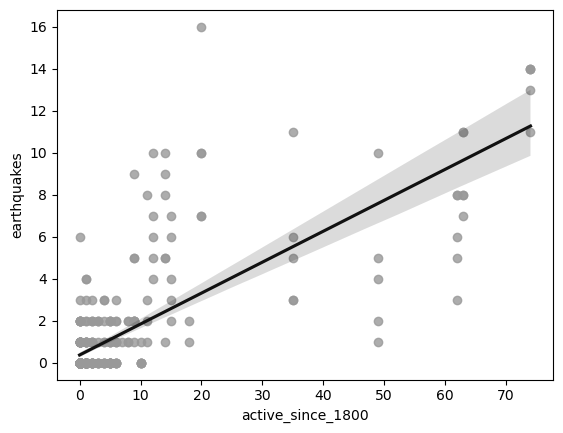

In [7]:
# 火山数と地震発生数の関係をプロット
import pandas as pd
import seaborn as sns

# 学習データ読込
df_train = pd.read_csv('https://raw.githubusercontent.com/ghmagazine/python_anomaly_detection_book/refs/heads/main/notebooks/datasets/earthquakes_volcanoes_2018-2022.csv')
# 火山数と地震発生数の単回帰直線と散布図をプロット
sns.regplot(df_train, x="active_since_1800", y="earthquakes",
            scatter_kws={'color':'#999999'}, line_kws={'color':'#111111'})

ドメイン知識の通り、説明変数候補`active_since_1800`と応答変数`earthquakes`には相関がありそうです。また年間の地震発生数は少数かつ一定の連続的な期間内に発生しており、ポアソン分布の適用に適した現象と言えるでしょう。よって`active_since_1800`を説明変数$x$として使用し、ポアソン回帰によるモデル構築を実施します。

## B. モデルの学習

ベイズ線形回帰や二項ロジスティック回帰と同様、以下の4ステップに分けてMCMC（PyMC）を用いたポアソン回帰モデルの学習法（MCMCサンプリングの方法）を解説します。

- I. MCMCの実行
- II. 収束の確認
- III. 学習データからしきい値を計算
- IV. MCMC サンプルを保存

### I. MCMCの実行

まずデータの読み込みと前処理を行います。

In [8]:
# データの読み込みと前処理
import pandas as pd

###### 学習データの読み込みと前処理######
# 学習データ読込
df_train = pd.read_csv('https://raw.githubusercontent.com/ghmagazine/python_anomaly_detection_book/refs/heads/main/notebooks/datasets/earthquakes_volcanoes_2018-2022.csv')
# 学習データの説明変数x、応答変数yを別々に保持してndarray化
x_train = df_train['active_since_1800'].to_numpy()
y_train = df_train['earthquakes'].to_numpy()

次にモデル式を記述し、MCMCを実行します。線形回帰モデルの場合と同様、pm.Model クラス内に事前分布、線形予測子、確率分布を記述します。
また線形回帰モデルでは記述しなかったリンク関数に関しても、その逆関数（シグモイド関数`pm.math.invlogit`）を明記する必要があります。

In [9]:
# MCMCによるポアソン回帰モデルのパラメータ推定
import pymc as pm

###### 学習ステップ1. 正常のモデルを作成する ######
seed=42  # 乱数シードを指定（結果の再現性を担保）
# モデル定義用のインスタンスを作成
poisson_regression_model = pm.Model()
# モデル式を記述
with poisson_regression_model:
    # 説明変数xを観測値として定義
    x = pm.Data("x", x_train, dims="record")
    # 事前分布（無情報に近づくよう分散の広い分布を使用する）
    w_0 = pm.Normal("w_0", mu=0, sigma=100)
    w_1 = pm.Normal("w_1", mu=0, sigma=100)
    # 線形予測子（rhoのMCMCサンプルが出力されないよう`pm.Deterministic`は使用しない）
    rho = w_0 + w_1*x
    # リンク関数の逆関数（muのMCMCサンプルが出力されないよう`pm.Deterministic`は使用しない）
    mu = pm.math.exp(rho)
    # 確率分布
    y = pm.Poisson("y", mu=mu, observed=y_train, dims="record")
# MCMCの実行（学習）
with poisson_regression_model:
    trace = pm.sample(random_seed=seed)
# 得られた事後分布を表示
trace.posterior

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [w_0, w_1]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


<xarray.Dataset> Size: 72kB
Dimensions:  (chain: 4, draw: 1000)
Coordinates:
  * chain    (chain) int64 32B 0 1 2 3
  * draw     (draw) int64 8kB 0 1 2 3 4 5 6 7 ... 993 994 995 996 997 998 999
Data variables:
    w_0      (chain, draw) float64 32kB -0.5825 -0.5051 ... -0.4852 -0.4436
    w_1      (chain, draw) float64 32kB 0.04419 0.04327 ... 0.04464 0.04362
Attributes:
    created_at:                 2025-12-31T17:07:05.188848+00:00
    arviz_version:              0.22.0
    inference_library:          pymc
    inference_library_version:  5.26.1
    sampling_time:              0.609778881072998
    tuning_steps:               1000

`pm.model_to_graphviz`関数を用いてグラフィカルモデルを可視化します。

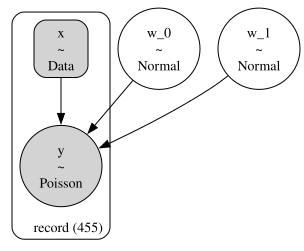

In [10]:
pm.model_to_graphviz(poisson_regression_model)

書籍本文の図8.19と同様のモデルが定義できていることがわかります。

### II. 収束の確認

[ArviZ](https://www.arviz.org/en/latest/)の`az.plot_trace`関数で事後分布とトレースプロットをプロットし、`az.summary`関数でMCMCサンプルの概要を表示します。

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
w_0,-0.496,0.062,-0.611,-0.379,0.001,0.001,1742.182,2404.436,1.001
w_1,0.044,0.001,0.041,0.047,0.000,0.000,1529.053,2133.261,1.001


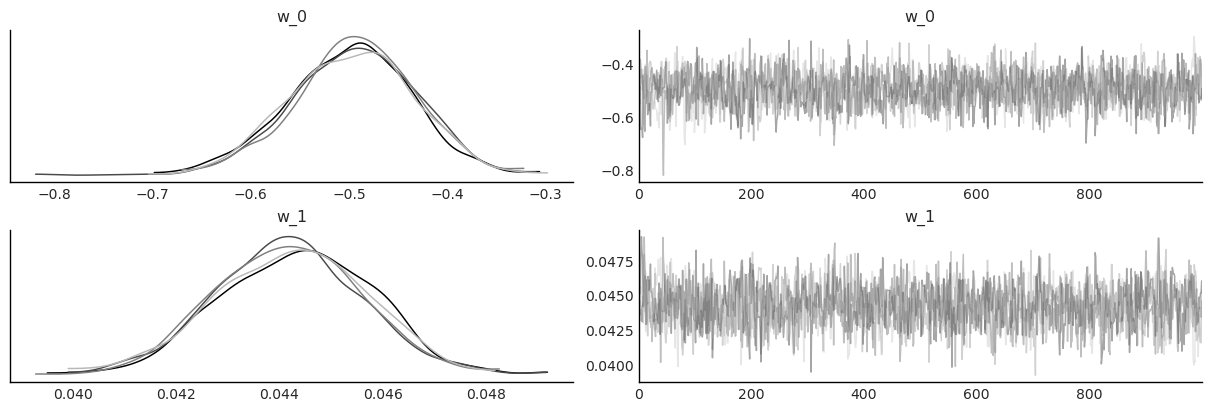

In [11]:
# トレースプロットとr_hat による収束の確認
import arviz as az

# トレースプロット
az.style.use("arviz-grayscale")
az.plot_trace(trace, combined=False, compact=False)
# 各パラメータのMCMCサンプルの概要を表示
az.summary(trace, round_to=3)

パラメータ`w_0`、`w_1`ともに、各チェーンの事後分布の形状がほぼ等しくなっており、`r_hat`が1に非常に近い値となっているため、収束していると判断できそうです（`ess_bulk`も400以上となっており、MCMCのサンプルサイズも足りていそうです）。

また、説明変数$x$（火山数`active_since_1800`）に対する傾きである`w_1`の`hdi_3%`（下側の3%信用区間）が0.041となっており、統計検定の観点からは、傾きが0よりも有意に⼤きいとみなせそうです。よって「火山数が多いほど地震の発生率が高い」という仮定が、統計的に裏付けられていることがわかります。

この傾向を可視化するため、横軸に説明変数$x$（火山数`active_since_1800`）をとって平均発生数パラメータ$\mu$の事後分布（$w_0$、$w_1$のMCMCサンプル$w_0^{(t)}$、$w_1^{(t)}$を用いて$\mu^{(t)}=w_1^{(t)}x+w_0^{(t)}$からMCMCサンプルを求める）をプロットしてみます。

<Axes: xlabel='active_since_1800 (x)', ylabel='$\\mu$'>

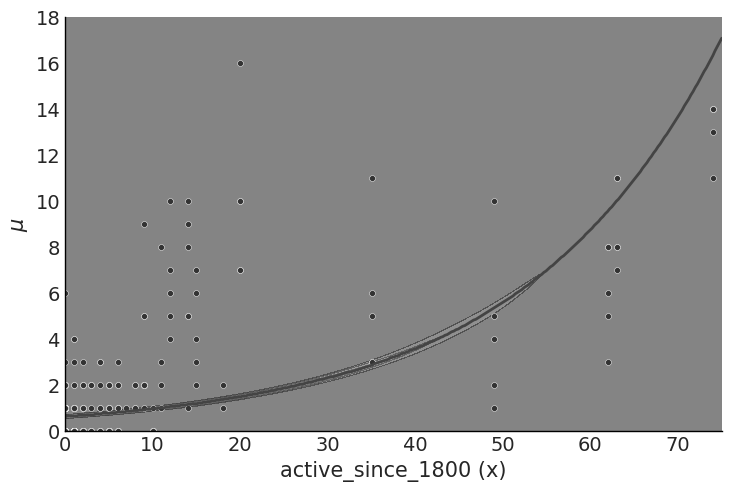

In [12]:
# 年齢xと成功率μの事後分布の関係を可視化
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import xarray as xr
from scipy import stats
import numpy as np

# (x,μ)格子点を作成
x_grid = np.linspace(0, 75, num=300)
mu_grid = np.linspace(0, 18, num=600)
X, MU = np.meshgrid(x_grid, mu_grid)
# 線形予測子rhoの事後分布のMCMCサンプルを計算
rho_posterior = trace.posterior["w_0"] + trace.posterior["w_1"]*xr.DataArray(x_grid, dims=["record"])
# 平均パラメータmuの事後分布のMCMCサンプルを計算
mu_posterior = np.exp(rho_posterior)
# xの値ごとにmuの事後分布の確率密度関数を計算
pdf_all_grid = []
map_grid = []  # MAP推定値
for x_idx, x_i in enumerate(x_grid):
    mu_posterior_i = mu_posterior[:, :, x_idx].to_numpy()
    # KDEでmuの事後分布分布の確率密度関数を計算
    kernel = stats.gaussian_kde(mu_posterior_i.ravel())
    pdf_i = kernel(mu_grid)  # 確率密度
    map_i = mu_grid[np.argmax(pdf_i)]
    # データを保持
    pdf_all_grid.append(pdf_i)
    map_grid.append(map_i)
pdf_grid_pivot = np.array(pdf_all_grid).T
# 確率密度をプロット
plt.contourf(X, MU, pdf_grid_pivot, levels=10, cmap=cm.gray, alpha=0.5)
plt.plot(x_grid, map_grid, color='#444444', lw=2)
plt.xlabel('active_since_1800 (x)')
plt.ylabel(r'$\mu$')
###### 学習データを散布図で描画 ######
sns.scatterplot(x=x_train, y=y_train,
                c='#333333', s=18, marker="o")

太線は事後分布のMAP推定値（最頻値）を、重ねてプロットしている散布図は学習データを示しています。このグラフからも、火山数（横軸）が増えるほど$\mu$の事後分布が上側にシフトしていることがわかります。

さらに、今回はパラメータが2個しかないので、KDEで連続化した事後分布を`az.plot_kde`関数で2次元プロットし、パラメータの事後分布間の相関関係を確認することもできます。

<Axes: >

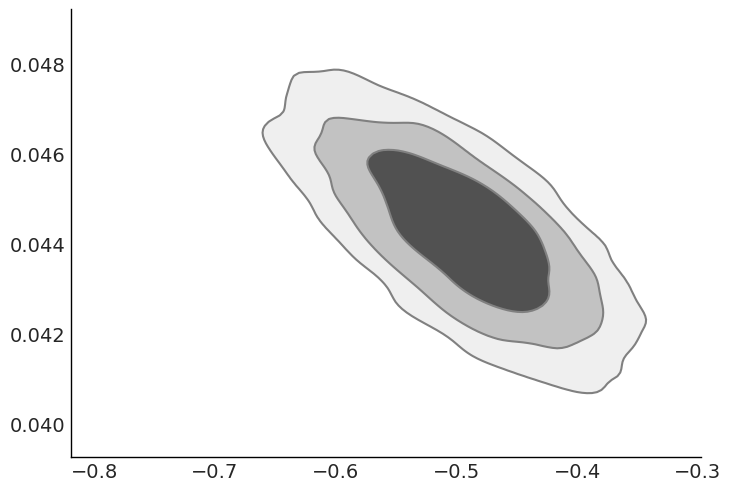

In [13]:
# パラメータw_0とw_1の事後分布の等高線プロットによる可視化
az.plot_kde(
    az.extract(trace, var_names="w_0"),
    az.extract(trace, var_names="w_1"),
    contourf_kwargs={"cmap": "Grays"}
)

横軸が`w_0`、縦軸が`w_1`を表しています。事後分布が斜めに偏在しており、両パラメータ間に相関があることがわかります。二項ロジスティック回帰の場合と同様、このような事後分布の相関関係はパラメータの識別可能性が低いことを示唆する場合があるため、後ほどデータの中央化による対処法を紹介します。今回は相関が二項ロジスティック回帰の実装例ほど強くなく、かつトレースプロットや`r_hat`、`ess_bulk`のような収束性を表す指標も良好なため、特に対処はせず実装を進めます。

また参考までに、説明変数$x$（火山数`active_since_1800`）を横軸にとった、応答変数$y$（年間地震発生数`earthquakes`）の予測分布の変化をプロットしてみます。

Text(-1.3885555555555538, 0.5, 'earthquakes')

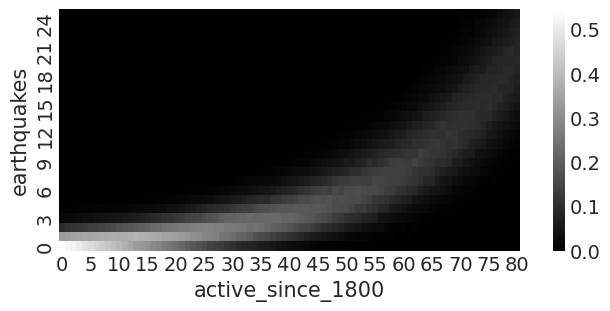

In [14]:
# 応答変数の予測分布（確率質量関数）を可視化
import collections

X_BY = 4
X_CENTER = 28
N_IMAGES = 4
x_borders = [X_CENTER - X_BY*(N_IMAGES/2-1) + X_BY*i for i in range(N_IMAGES-1)]

def calc_pm_list(posterior_predictive, y_list):
    """確率質量を求める関数（MCMCサンプルが存在しないときはKDEで近似的に求める）"""
    count_dict = collections.Counter(posterior_predictive.ravel())
    kernel = stats.gaussian_kde(posterior_predictive.ravel())
    pmf_list = []
    for y in y_list:
        # MCMCサンプルにyが存在するとき、そのカウント数を確率質量とする
        if y in count_dict.keys():
            pmf_list.append(count_dict[y]/posterior_predictive.size)
        # MCMCサンプルにyが存在しないとき、KDEで近似的に確率質量を求める
        else:
            pmf_list.append(kernel(y)[0])
    return np.array(pmf_list)

# 描画用のFigureとAxesを生成
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6, 3))

# (x,y)格子点を作成
x_grid = np.linspace(0, 80, num=81)
y_grid = np.arange(0, 26)
X, Y = np.meshgrid(x_grid, y_grid)
# 線形予測子rhoの事後分布のMCMCサンプルを計算
rho_posterior = trace.posterior["w_0"] + trace.posterior["w_1"]*xr.DataArray(x_grid, dims=["record"])
# 平均パラメータmuの事後分布のMCMCサンプルを計算
mu_posterior = np.exp(rho_posterior)
# xの値ごとに予測分布を計算
pmf_all_grid = []
map_grid = []  # MAP推定値
for x_idx, x_i in enumerate(x_grid):
    mu_posterior_i = mu_posterior[:, :, x_idx].to_numpy()
    # 予測分布のMCMCサンプルを計算
    posterior_predictive = stats.poisson.rvs(
        mu=mu_posterior_i,
        size=mu_posterior_i.shape,
        random_state=seed
    )
    # yの値ごとに確率質量と異常度を計算
    pmf_i = calc_pm_list(posterior_predictive, y_grid)  # 確率質量計算用の関数
    #pmf_i = stats.poisson.pmf(y_grid, mu=np.mean(posterior_predictive.ravel()))
    map_i = y_grid[np.argmax(pmf_i)]
    # データを保持
    pmf_all_grid.append(pmf_i)
    map_grid.append(map_i)
pmf_grid_pivot = np.array(pmf_all_grid).T
# 確率質量をプロット
sns.heatmap(pmf_grid_pivot, cmap=cm.gray, ax=ax)
ax.invert_yaxis()
ax.set_xlabel('active_since_1800')
ax.set_ylabel('earthquakes')

説明変数$x$が大きくなると予測分布であるポアソン分布の期待値（期待発生回数パラメータ）が高頻度側にシフトし、また分布の幅が広くなって中心であっても確率質量が小さくなっていくことが分かります。この現象は書籍5.4.2節で言及した、「観測区間$t$が小さい場合の確率質量が全体的に⼤きくなる現象」と類似しています。今回は観測区間$t$が常に1年で変化しませんが、$x$が同様の役割を果たします。より詳しく説明すると、「$x$が⼤きい方が、$y$の広い範囲にわたって確率質量が無視できない⼤きさとなり、$y$が実効的に定義される点の数が増え、1点あたりに割り振られる確率質量が⼩さくなる」という現象が起こっています。これにより$x$が大きいほど誤報率がターゲットよりも高くなり、誤報率を一定にコントロールできなくなってしまいます。

このような誤報率の意図せぬ変動を防ぐため、二項ロジスティック回帰と同様に異常度は用いず、ポアソン分布の累積分布関数に基づき$y$に直接しきい値を設ける方法をとります。

### III. 学習データからしきい値を計算

ポアソン回帰では、しきい値の算出に推論データの説明変数$\boldsymbol{x}$が必要となるため、学習段階ではしきい値を決定できません。推論フェーズであらためて算出します。

### IV. 学習で求めたMCMCサンプルを保存

学習で求めたMCMCサンプルをnetCDF形式で保存し、推論フェーズで再利用できるようにします。

In [15]:
# 学習で求めたMCMC サンプルの保存
filepath_mcmc = './8_6_mcmc_samples.nc' # モデルの保存ファイル名
trace.posterior.to_netcdf(filepath_mcmc)

## C. 推論

推論フェーズでは、学習フェーズで求めたパラメータ$w_1,w_0$のMCMCサンプル、および推論データの説明変数$\boldsymbol{x}$、応答変数$y$を用いて、以下の推論手順にしたがい異常判定を実施します。

- 学習で得たパラメータ$w_1,w_0$のMCMCサンプルと推論データの説明変数$x$から、モンテカルロ積分により予測分布のMCMCサンプルを得る
- 予測分布のMCMCサンプルの分位点とターゲットとする誤報率に基づき、応答変数yの上下のしきい値を求める
- 推論データの応答変数$y$が、このしきい値の範囲外にあれば異常あり、範囲内にあれば異常なしと判定する

まずは以下のように、学習時に保存したMCMCサンプルを読み込みます。

In [16]:
# 学習時に保存したMCMCサンプルの読み込み
import xarray as xr

# MCMCサンプルを読み込み
filepath_mcmc = './8_6_mcmc_samples.nc'
posterior_mcmc = xr.load_dataset(filepath_mcmc)

次に以下のように、推論データ（2023年のデータ）の読み込みと前処理を実施します。

In [17]:
# 推論データの読み込みと前処理
# 火山数と地震の発生回数データ
df_inference = pd.read_csv('https://raw.githubusercontent.com/ghmagazine/python_anomaly_detection_book/refs/heads/main/notebooks/datasets/earthquakes_volcanoes_2023.csv')
# 学習データの説明変数x、応答変数yを別々に保持してndarray化
x_inference = df_inference['active_since_1800'].to_numpy()
y_inference = df_inference['earthquakes'].to_numpy()

ここから以下のように、予測分布のMCMCサンプルの算出としきい値判定を実施します。

In [18]:
# 予測分布のMCMCサンプルの算出としきい値による異常判定
import numpy as np
from scipy import stats

seed=42 # 乱数シードを指定（結果の再現性を担保）
TARGET_FP_RATE = 0.0027 # ターゲットとする誤報率（正規分布の3σ相当=0.0027）
# 線形予測子rhoの事後分布のMCMCサンプルを計算
x_inference_xr = xr.DataArray(x_inference, dims=["record"])
rho_posterior = posterior_mcmc["w_0"] + posterior_mcmc["w_1"]*x_inference_xr
# 平均パラメータmuの事後分布のMCMCサンプルを計算
mu_posterior = np.exp(rho_posterior)
# 推論データ(y, n, x)から予測分布のMCMCサンプルを計算し、しきい値判定
predictions = []
for i, y in enumerate(y_inference):  # データごとに予測分布を計算
    mu_posterior_i = mu_posterior[:, :, i].to_numpy()
    # muとnから予測分布のMCMCサンプルを計算
    posterior_predictive = stats.poisson.rvs(
        mu=mu_posterior_i,
        size=mu_posterior_i.shape,
        random_state=seed
    )
    # 下側しきい値（MCMCサンプルの、ターゲットとする誤報率と等しい分位点）
    th_lower = np.quantile(posterior_predictive, TARGET_FP_RATE/2)
    # 上側しきい値（MCMCサンプルの、ターゲットとする誤報率と等しい分位点）
    th_upper = np.quantile(posterior_predictive, 1 - TARGET_FP_RATE/2)
    # しきい値判定
    pred = np.where((y < th_lower) | (y > th_upper), 'anomaly', 'normal')
    predictions.append(str(pred))

判定のしきい値を超えた国の一覧を、地震（マグニチュード6以上）の発生数が多い順にリストアップします。

In [19]:
# 異常判定のしきい値を超えた国のリストアップ
# 推論結果を表示（しきい値を超えた国）
df_inference['prediction'] = predictions
print(df_inference[df_inference['prediction'] == 'anomaly'][
    ['country', 'year', 'earthquakes', 'active_since_1800']].sort_values(
    'earthquakes', ascending=False).reset_index(drop=True))

            country  year  earthquakes  active_since_1800
0       Philippines  2023           15                 14
1  Papua New Guinea  2023           10                 20
2             Tonga  2023            8                 15
3           Vanuatu  2023            8                 12
4         Argentina  2023            7                  6
5       Afghanistan  2023            6                  0
6       New Zealand  2023            6                  9
7            Turkey  2023            6                  2


これらの国は2023年に、火山数から予測されるよりも多くの地震が、偶然の範囲を超えて発生したと言えます。

推論の結果、異常と判定される範囲を推論データと重ねて可視化してみます。

Text(0, 0.5, 'earthquakes')

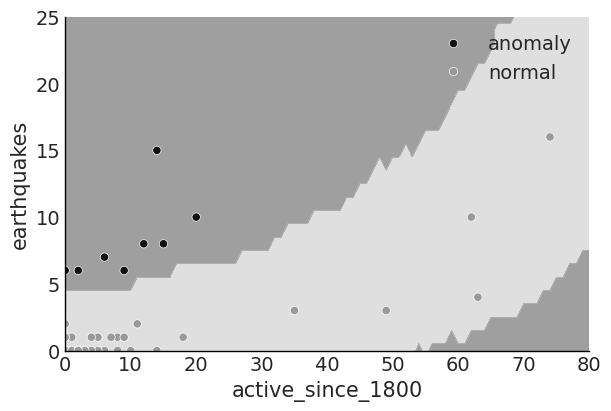

In [ ]:
# 正常と異常の境界をプロット
# 描画用のFigureとAxesを生成
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6, 4))

# (x,y)格子点を作成
x_grid = np.linspace(0, 80, num=81)
y_grid = np.arange(0, 26)
X, Y = np.meshgrid(x_grid, y_grid)
# 線形予測子rhoの事後分布のMCMCサンプルを計算
rho_posterior = posterior_mcmc["w_0"] + posterior_mcmc["w_1"]*xr.DataArray(x_grid, dims=["record"])
# 平均パラメータmuの事後分布のMCMCサンプルを計算
mu_posterior = np.exp(rho_posterior)
# xの値ごとに予測分布を計算
pred_all_grid = []
for x_idx, x_i in enumerate(x_grid):
    mu_posterior_i = mu_posterior[:, :, x_idx].to_numpy()
    # 予測分布のMCMCサンプルを計算
    posterior_predictive = stats.poisson.rvs(
        mu=mu_posterior_i,
        size=mu_posterior_i.shape,
        random_state=seed
    )
    # 下側しきい値（MCMCサンプルとターゲットとする誤報率から計算）
    th_lower = np.quantile(posterior_predictive, TARGET_FP_RATE/2)
    # 上側しきい値（MCMCサンプルとターゲットとする誤報率から計算）
    th_upper = np.quantile(posterior_predictive, 1 - TARGET_FP_RATE/2)
    # しきい値判定
    pred = np.where((y_grid < th_lower) | (y_grid > th_upper), 0, 1)
    # データを保持
    pred_all_grid.append(pred)
pred_all_pivot = np.array(pred_all_grid).T
# 確率質量をプロット
ax.contourf(X, Y, pred_all_pivot, levels=1, cmap=cm.gray, alpha=0.5)
###### 推論データを散布図で描画 ######
sns.scatterplot(x=x_inference, y=y_inference, hue=predictions,
                palette=['#111111', '#999999'], ax=ax)
ax.set_xlabel('active_since_1800')
ax.set_ylabel('earthquakes')

火山の数が多いほど、地震発生数における正常と異常の境界が高頻度側にシフトしていることがわかります。

## Tips：パラメータの識別可能性とデータの中心化による対処

二項ロジスティック回帰の場合と同様に、パラメータの識別可能性が低いことが疑われる場合、データを中心化することで対処可能です。

パラメータの識別可能性を判断するためには、先ほどのようにパラメータの事後分布の相関関係を見ることが有効です（ポアソン回帰はパラメータが2個しかないので可視化できる）。他にも`r_hat`、`ess_bulk`のような収束性を表す指標が悪い場合も、識別可能性が低いことが原因である可能性があります。

このような識別可能性が低いことが疑われるケースでは、以下のようにデータを中心化してからMCMCを実行します。

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [w_0_c, w_1_c]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
w_0_c,-0.266,0.056,-0.370,-0.163,0.001,0.001,2042.757,2411.304,1.0
w_1_c,0.044,0.001,0.042,0.047,0.000,0.000,2078.636,2576.372,1.0


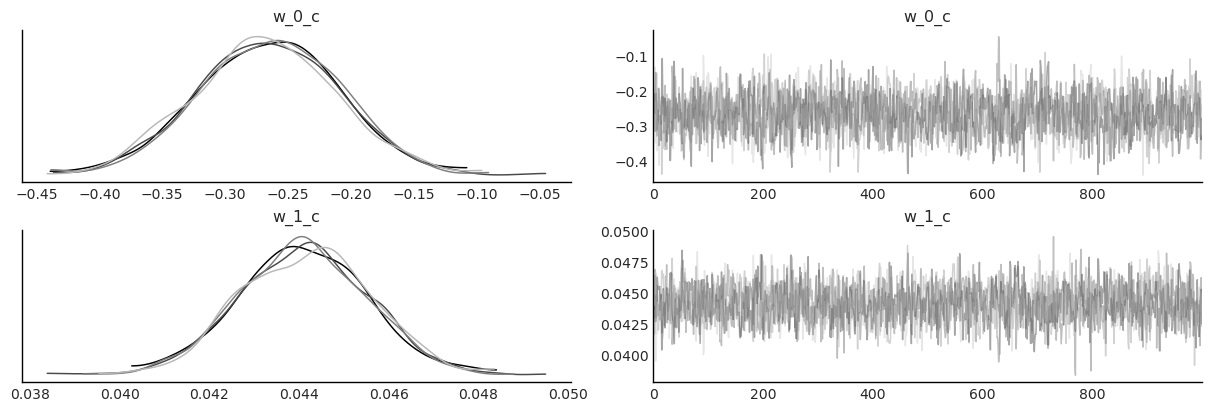

In [21]:
# 中心化してMCMCを再実行
x_mean = x_train.mean()

# モデル定義用のインスタンスを作成
poisson_regression_model = pm.Model()
# モデル式を記述
with poisson_regression_model:
    # 中心化した説明変数x_cと試行数nを観測値として定義
    x_c = pm.Data("x", x_train - x_mean, dims="record")
    # 事前分布（無情報に近づくよう分散の広い分布を使用する）
    w_0_c = pm.Normal("w_0_c", mu=0, sigma=100)  # 中心化後のパラメータであることを明示的に示すため名前変更
    w_1_c = pm.Normal("w_1_c", mu=0, sigma=100)
    # 線形予測子（rhoのMCMCサンプルが出力されないよう`pm.Deterministic`は使用しない）
    rho = w_0_c + w_1_c*x_c  # 中心化した説明変数を渡す
    # リンク関数の逆関数
    # （muのMCMCサンプルが出力されないよう`pm.Deterministic`は使用しない）
    mu = pm.math.exp(rho)
    # 確率分布
    y = pm.Poisson("y", mu=mu, observed=y_train, dims="record")

# MCMCの実行（学習）
with poisson_regression_model:
    trace = pm.sample(random_seed=seed)
# 得られた事後分布を表示
trace.posterior

# トレースプロット
az.style.use("arviz-grayscale")
az.plot_trace(trace, combined=False, compact=False)
# 各パラメータのMCMCサンプルの概要を表示
az.summary(trace, round_to=3)

中心化する前と比べて、`r_hat`や`ess_bulk`のような収束性を表す指標がやや向上しています。

また、推定されたパラメータの平均値`mean`は先ほど述べた以下の関係を満たしており、中心化前後の推定されたモデルはほぼ等価であるとみなせそうです。

- 中心化後の$\tilde{w_1}$（式中の`w_1_c`）=中心化前の$w_1$
- 中心化後の$\tilde{w_0}$（式中の`w_0_c`）=中心化前の$w_0+w_1\hat{\mu}$（参考までに、$x$の標本平均$\hat{\mu}\simeq 5.12$）

<Axes: xlabel='active_since_1800 (x)', ylabel='$\\mu$'>

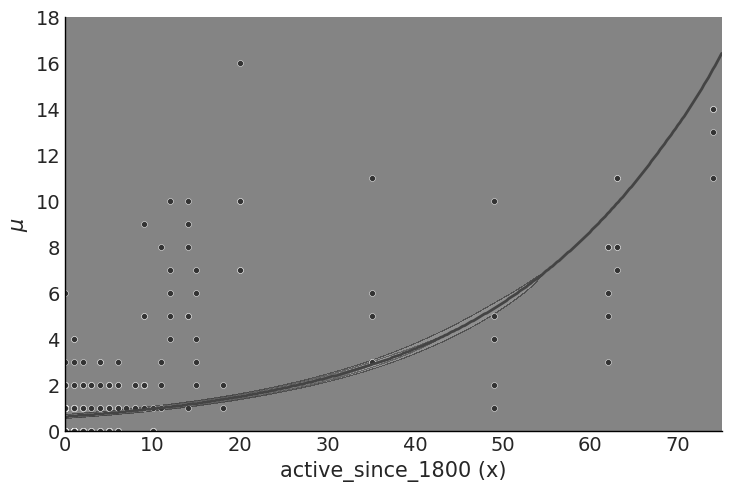

In [22]:
# (x,μ)格子点を作成
x_grid = np.linspace(0, 75, num=300)
mu_grid = np.linspace(0, 18, num=600)
X, MU = np.meshgrid(x_grid, mu_grid)
# 中心化したx_grid
x_grid_c = x_grid - x_mean

# 線形予測子rhoの事後分布のMCMCサンプルを計算
rho_posterior = trace.posterior["w_0_c"] + trace.posterior["w_1_c"]*xr.DataArray(x_grid_c, dims=["record"])
# 平均パラメータmuの事後分布のMCMCサンプルを計算
mu_posterior = np.exp(rho_posterior)
# xの値ごとにmuの事後分布の確率密度関数を計算
pdf_all_grid = []
map_grid = []  # MAP推定値
for x_idx, x_i in enumerate(x_grid):
    mu_posterior_i = mu_posterior[:, :, x_idx].to_numpy()
    # KDEでmuの事後分布分布の確率密度関数を計算
    kernel = stats.gaussian_kde(mu_posterior_i.ravel())
    pdf_i = kernel(mu_grid)  # 確率密度
    map_i = mu_grid[np.argmax(pdf_i)]
    # データを保持
    pdf_all_grid.append(pdf_i)
    map_grid.append(map_i)
pdf_grid_pivot = np.array(pdf_all_grid).T
# 確率密度をプロット
plt.contourf(X, MU, pdf_grid_pivot, levels=10, cmap=cm.gray, alpha=0.5)
plt.plot(x_grid, map_grid, color='#444444', lw=2)
plt.xlabel('active_since_1800 (x)')
plt.ylabel(r'$\mu$')
###### 学習データを散布図で描画 ######
sns.scatterplot(x=x_train, y=y_train,
                c='#333333', s=18, marker="o")

得られた事後分布自体は、中心化前とほぼ一致していることがわかります。

パラメータ`w_0_c`と`w_1_c`の事後分布を2次元KDEで可視化してみます。

<Axes: >

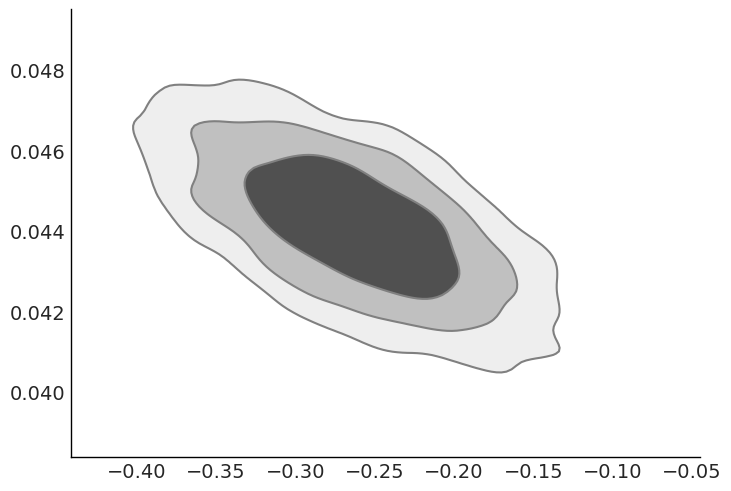

In [23]:
# パラメータw_0とw_1の事後分布の等高線プロットによる可視化
az.plot_kde(
    az.extract(trace, var_names="w_0_c"),
    az.extract(trace, var_names="w_1_c"),
    contourf_kwargs={"cmap": "Grays"}
)

パラメータ間の相関はほとんど緩和されていないことが分かります。今回のケースでは中心化はパラメータ間の相関緩和に寄与しなかったため、他の原因がありそうです。収束性自体は悪くないので、ここではこれ以上の原因調査は行わずに処理を終了します。